Начнем с простого вопроса: что произойдет в результате выполнения следующей команды?

`import pandas as pnds`

* [ ] Сможем использовать библиотеку pandas, обращаясь и как pandas, и как pnds
* [x] Сможем использовать библиотеку pandas, обращаясь к ней как pnds
* [ ] Вовсе не сможем использовать библиотеку, потому что использовали сокращение pnds, а не pd

# 1

Работаем с данными о поездках на такси в Нью-Йорке, в которых также имеется информация о погодных условиях и выходных днях.

* `pickup_dt` - период с точностью до часа
* `pickup_month` -  месяц
* `borough` - район Нью-Йорка, из которого был сделан заказ (5 районов + аэропорт)
* `pickups` - число поездок за период (час)
* `hday` - является ли день праздничным/выходным: Y - да, N - нет
* `spd` - скорость ветра в милях в час
* `vsb` - видимость
* `temp` - температура в градусах Фаренгейта
* `dewp` - точка росы по Фаренгейту
* `slp` - давление
* `pcp_01` - количество осадков за час
* `pcp_06` -  количество осадков за 6 часов
* `pcp_24` -  количество осадков за 24 часа
* `sd` - глубина снега в дюймах

In [1]:
import pandas as pd
from pathlib import Path

path_to_file = "data/2_taxi_nyc.csv"

taxi = pd.read_csv(path_to_file)

Посмотреть разбор задания можно по ссылке https://youtu.be/tVz7oSoFezU

# 2

In [2]:
taxi.shape

(29101, 14)

Проверьте, сколько всего строк и столбцов имеется в датасете.

* [ ] 21715 столбцов, 14 строк
* [x] 29101 строка, 14 столбцов
* [ ] 29101 столбец, 14 строк
* [ ] 26058 строк, 14 столбцов
* [ ] 21715 строк, 14 столбцов

# 3

In [3]:
taxi.dtypes

pickup_dt           str
pickup_month        str
borough             str
pickups           int64
hday                str
spd             float64
vsb             float64
temp            float64
dewp            float64
slp             float64
pcp 01          float64
pcp 06          float64
pcp 24          float64
sd              float64
dtype: object

Давайте посмотрим на типы колонок. Все ли из них считались правильно? В качестве ответа выберите тип, преобладающий в датасете.

* [ ] datetime64
* [x] float64
* [ ] object
* [ ] int64

# 4

В названиях столбцов pcp 01, pcp 06, pcp 24 встречается пробел. Это не очень удобно, если в дальнейшем вы планируете обращаться к колонкам через точку, без использования кавычек и скобочек. 

Замените пробел в названиях на знак нижнего подчеркивания. 

Данные сохранены в переменную taxi. Данные должны быть изменены в этом же датафрейме.

In [4]:
taxi.columns = [column.replace(' ', '_') for column in taxi.columns]

In [8]:
taxi.head()

,pickup_dt,pickup_month,borough,pickups,hday,spd,vsb,temp,dewp,slp,pcp_01,pcp_06,pcp_24,sd
0,2015-01-01 01:00:00,Jan,Bronx,152,Y,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0
1,2015-01-01 01:00:00,Jan,Brooklyn,1519,Y,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00,Jan,EWR,0,Y,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0
3,2015-01-01 01:00:00,Jan,Manhattan,5258,Y,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0
4,2015-01-01 01:00:00,Jan,Queens,405,Y,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0


Посмотреть разбор задания можно по ссылке https://youtu.be/RhSDLRCVm18

# 5

Вас попросили узнать, сколько записей (строк) в датафрейме относятся к району Манхэттен (Manhattan). Получить ответ на данный вопрос можно было бы, например, с помощью следующей команды:

`taxi.query("borough == 'Manhattan'").shape[0]`


А если мы хотим посмотреть, сколько раз встречается каждый из районов? Неужели придется использовать подобную конструкцию для каждого уровня переменной? Здесь на помощь приходит метод value_counts(), подробнее о котором можно почитать в конспекте! 

А теперь вопрос: сколько раз в данных встречается район Бруклин (Brooklyn)? `4343`

In [11]:
taxi['borough'].value_counts()

borough
Bronx            4343
Brooklyn         4343
EWR              4343
Manhattan        4343
Queens           4343
Staten Island    4343
Name: count, dtype: int64

Посмотреть разбор задания можно по ссылке https://www.youtube.com/watch?v=t_pGegvrFX4

# 6

Следующая задача: выяснить, из какого района было совершено наибольшее количество поездок за весь период. 

Для начала посчитайте общее количество поездок (pickups), без группировки.

In [12]:
taxi.pickups.sum()

np.int64(14265773)

Ответ: 14265773

Посмотреть разбор задания можно по ссылке https://youtu.be/nhK7pP9JNtM

# 7

А теперь сгруппируйте данные по району (borough) и укажите, из какого пункта было совершено больше всего поездок.

In [13]:
taxi.groupby('borough').agg({'pickups': 'sum'})

,pickups
borough,
Bronx,220047
Brooklyn,2321035
EWR,105
Manhattan,10367841
Queens,1343528
Staten Island,6957


* [ ] Brooklyn
* [ ] Staten Island
* [ ] Queens
* [ ] Bronx
* [x] Manhattan

# 8

⭐️Задание со звёздочкой!⭐️

Еще несколько полезных методов в pandas! Возможно, в предыдущем степе вы просто посмотрели на данные или отсортировали значения. Ускорить данный процесс в дальнейшем помогут методы idxmin() и idxmax(), которые возвращают индекс минимального или максимального значения.

`idxmin` – индекс минимального значения
`idxmax` – индекс максимального значения

Сохраните название района с наименьшим числом поездок в переменную min_pickups, применив подходящий метод.

Исходные данные сохранены в переменную taxi.

In [5]:
min_pickups = (taxi.groupby('borough').sum()['pickups']).idxmin()

In [14]:
min_pickups

'EWR'

Посмотреть разбор задания можно по ссылке https://youtu.be/0-eKFIXce0s

# 9

Продолжим изучение данных и посмотрим на число поездок в выходные дни. Сгруппируйте данные по двум признакам: району города и является ли день выходным (колонки borough и hday). Сравните среднее число поездок, и выберите районы, из которых по праздникам в среднем поступает больше заказов, чем в обычные дни. 

* [ ] Brooklyn
* [x] Queens
* [x] EWR
* [ ] Staten Island
* [ ] Manhattan
* [ ] Bronx

In [15]:
taxi.groupby(['borough', 'hday']).agg({"pickups": "mean"})

pickups
borough       hday             
Bronx         N       50.771073
              Y       48.065868
Brooklyn      N      534.727969
              Y      527.011976
EWR           N        0.023467
              Y        0.041916
Manhattan     N     2401.302921
              Y     2035.928144
Queens        N      308.899904
              Y      320.730539
Staten Island N        1.606082
              Y        1.497006

# 10

Для каждого района посчитайте число поездок по месяцам. Отсортируйте полученные значения по убыванию и сохраните результирующий датафрейм в pickups_by_mon_bor.

Обратите внимание, что итоговый датасет должен состоять из 3-х колонок - pickup_month, borough, pickups.

Данные сохранены в переменную taxi.

In [6]:
pickups_by_mon_bor = (
    taxi
    .groupby(['pickup_month', 'borough'], as_index=False)
    .agg({'pickups': 'sum'})
    .sort_values(by='pickups', ascending=False)
)

In [17]:
pickups_by_mon_bor.head()

,pickup_month,borough,pickups
21,Jun,Manhattan,1995388
33,May,Manhattan,1888800
9,Feb,Manhattan,1718571
27,Mar,Manhattan,1661261
3,Apr,Manhattan,1648278


Посмотреть разбор задания можно по ссылке https://youtu.be/ntEo2K0muHU

# 11

💀 Сложное задание! 💀

Теперь задача посложнее! Попрактикуемся в написании собственных функций и их применении к датафрейму. Поскольку данные о поездках в Нью-Йорке, температура представлена в градусах Фаренгейта. 

Напишите функцию temp_to_celcius, которая получает на вход колонку с температурой в °F и возвращает значения, переведенные в градусы Цельсия.

Формула:

 Celsius = \frac{(Fahrenheit-32) \cdot 5.0}{9.0}Celsius= 
9.0
(Fahrenheit−32)⋅5.0
​
 

Пример работы функции:

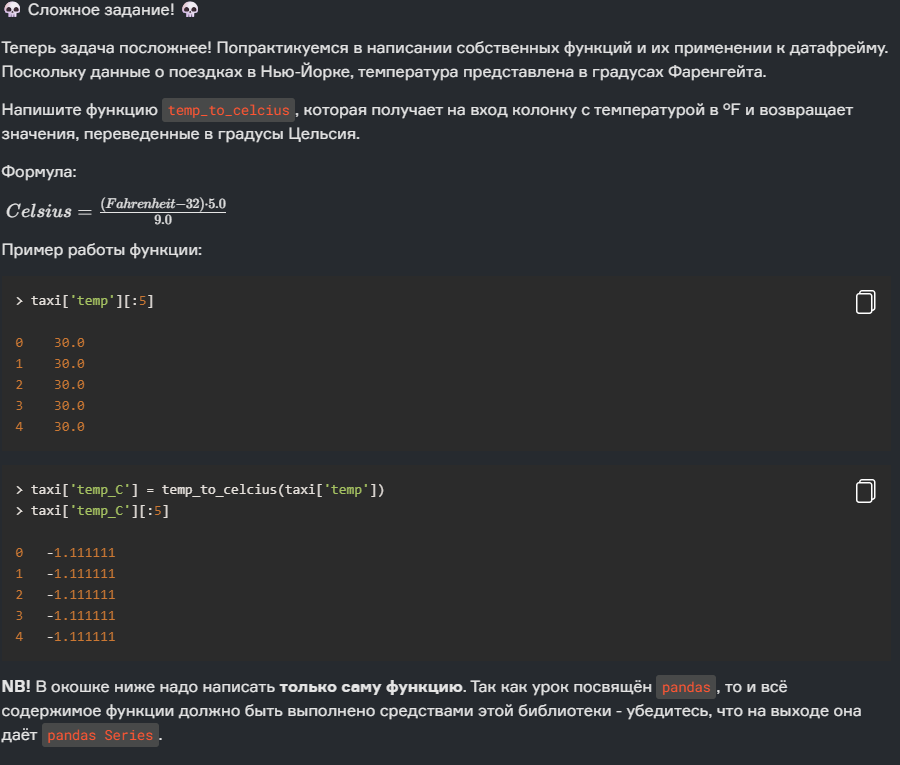

In [7]:
def temp_to_celcius(column):
    return (column - 32) * 5 / 9

Посмотреть разбор задания можно по ссылке https://youtu.be/pIRkDYJTz8c